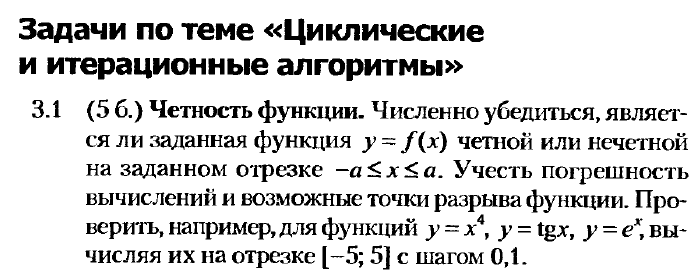

In [2]:
import math

def check_function_parity(func, a, step, epsilon=0.1):
    is_even = True
    is_odd = True
    
    # Генерируем значения x от -a до a (включительно)
    # Используем целые числа для итерации, чтобы избежать накопления ошибки шага
    n_steps = int(2 * a / step) + 1
    
    for i in range(n_steps):
        x = -a + i * step
        
        # Ограничиваем проверку положительной стороной (x > 0), 
        # так как мы сравниваем f(x) и f(-x)
        if x <= epsilon: 
            continue
            
        try:
            val_pos = func(x)
            val_neg = func(-x)
            
            # Проверка на четность: f(x) == f(-x)
            if not math.isclose(val_pos, val_neg, abs_tol=epsilon):
                is_even = False
                
            # Проверка на нечетность: f(-x) == -f(x)
            if not math.isclose(val_neg, -val_pos, abs_tol=epsilon):
                is_odd = False
                
        except (ValueError, ZeroDivisionError):
            # Обработка точек разрыва (например, tg(x) в определенных точках)
            print(f"Точка разрыва или неопределенности обнаружена в районе x = {x:.1f}")
            continue

        # Если оба флага уже False, можно закончить цикл раньше
        if not is_even and not is_odd:
            break

    if is_even:
        return "Четная"
    elif is_odd:
        return "Нечетная"
    else:
        return "Ни четная, ни нечетная (общего вида)"

# Тестируемые функции
functions = [
    ("y = x^4", lambda x: x**4),
    ("y = tg(x)", lambda x: math.tan(x)),
    ("y = e^x", lambda x: math.exp(x))
]

# Параметры задачи
a_val = 5
step_val = 0.1

print(f"Проверка функций на отрезке [{-a_val}, {a_val}] с шагом {step_val}:")
print("-" * 50)

for name, f in functions:
    result = check_function_parity(f, a_val, step_val)
    print(f"{name.ljust(10)} | Результат: {result}")

Проверка функций на отрезке [-5, 5] с шагом 0.1:
--------------------------------------------------
y = x^4    | Результат: Четная
y = tg(x)  | Результат: Нечетная
y = e^x    | Результат: Ни четная, ни нечетная (общего вида)
